In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from kanly.api import lm
import pprint
from scipy.stats import rv_discrete
from kanly.__sandbox__.generalized_synthetic_control.gsc import gsc, permutation_inference


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Your version of `kanly` is 0.0.1003 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛



# simulated data

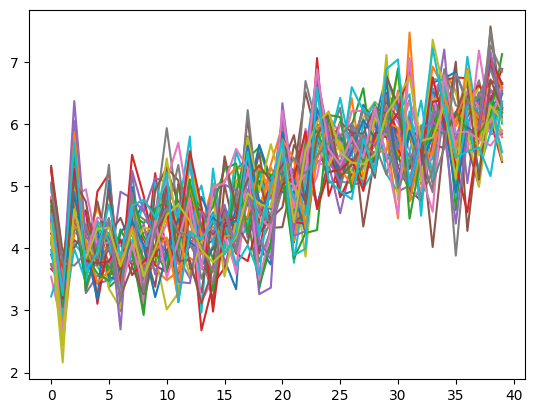

In [2]:
N = 40 # num units
T = 40 # num periods

np.random.seed(0)

# Factors
factors = np.random.randn(T,N)
for j in range(N):
    factors[:,j] += np.random.rand()/15 * np.arange(T)
weights = rv_discrete(values=([0,1,5],[.6,.3,.1])).rvs(size=(N,N)) # correlation structure

organic = factors @ weights # organic outcome
for j in range(N):
    organic[:,j] = (organic[:,j] - organic[:,j].mean()) / organic[:,j].std() + 5
    plt.plot(organic[:,j])

In [3]:
weights

array([[1, 5, 0, ..., 1, 0, 0],
       [0, 5, 0, ..., 0, 1, 0],
       [5, 0, 1, ..., 1, 5, 1],
       ...,
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 1, 0, 0],
       [5, 5, 0, ..., 0, 0, 0]])

In [4]:
df = pd.DataFrame({
    'organic': organic.flatten(),
    'unit': np.tile(range(N), T),
    'time': np.repeat(range(T), N),
})
df['time_numeric'] = df.time # can't have time index same as covariate, used later
df

,organic,unit,time,time_numeric
0,4.492755,0,0,0
1,4.621481,1,0,0
2,4.342573,2,0,0
3,5.257874,3,0,0
4,4.603371,4,0,0
...,...,...,...,...
1595,6.246586,35,39,39
1596,5.895890,36,39,39
1597,6.843259,37,39,39
1598,6.058653,38,39,39


In [5]:
# add treatments
np.random.seed(0)
NUM_TREATMENTS = 2
TREAT_COLS = [f'treatment_{t}' for t in range(NUM_TREATMENTS)]
df['outcome'] = df.organic
for t in range(NUM_TREATMENTS):
    treatment_units = np.random.choice(range(N), N // 4, replace=False)
    df[f'treatment_{t}'] = 0.0
    df.loc[df.unit.isin(treatment_units) & (df.time >= 2 * T // 3), f'treatment_{t}'] = 1.0

    df.outcome += 1.5 * (-1) ** t * df[f'treatment_{t}']
    
df.head()

,organic,unit,time,time_numeric,outcome,treatment_0,treatment_1
0,4.492755,0,0,0,4.492755,0.0,0.0
1,4.621481,1,0,0,4.621481,0.0,0.0
2,4.342573,2,0,0,4.342573,0.0,0.0
3,5.257874,3,0,0,5.257874,0.0,0.0
4,4.603371,4,0,0,4.603371,0.0,0.0


# fit model


Let $i=1,\dots,N$ denote units, $t=1,\dots,T$ denote time index and $y$ denote outcomes and $x$ denote covariates.  Let $D_{it}$ be the vector of treatment indicator (could be fractional) for unit $i$ in time $t$.

We want to find treatment effects $\hat\delta$ by solving the program

$$\min_{\delta,\gamma,\omega,\mu} \sum_{i=1}^{N}\sum_{t=1}^{T}w_{it}\,\left(y_{it}-\mu_{i}-D_{it}^\top\delta_{i}-x_{it}^{\top}\gamma_{i}-\sum_{j\ne i}\omega_{ij}\left(y_{jt}-\mu_{j}-D_{jt}^\top\delta_{j}-x_{jt}^{\top}\gamma_{j}\right)\right)^{2}$$
$$+\alpha\sum_{i}\lambda\left\Vert \omega_{i}\right\Vert _{1}+\frac{1-\lambda}{2}\left\Vert \omega_{i}\right\Vert _{2}^{2}$$

which means finding synthetic weights $\hat\omega$ and nuisance parameters on covariates $\hat\mu,\hat\gamma$.

The code below constructs the program and uses `kanly`'s nonlinear least squares functionality to solve it.

Inference is done conformally by shifting the treatment vectors through time and reestimating the model to form a null distribution.

In [6]:
from kanly.optimize.bfgs_bounded_quasi_newton import bfgs_pqn
# bfgs_pqn()

In [7]:
from __future__ import absolute_import, print_function

import numpy as np
import pandas as pd

from tqdm import tqdm
from kanly.regression.nonlinear_least_squares.optimize.nlls_coordinate_descent_minimize_internal import \
    nlls_elastic_net_minimize_internal_coordinate_descent
from kanly.optimize.bfgs_bounded_quasi_newton import bfgs_pqn

def get_gsc_pred_func(data, outcome_col, unit_col, time_col, treatment_cols, covariate_cols=None,
                      log_transform=False, debug=True, pooled_treatment=False, shift=0, weight_col=None,
                      fit_only_treatment_units=True, weight_control_only=False,
                      permute=None):
    if covariate_cols is None:
        covariate_cols = []

    df_unit_pivot = pd.pivot(data, index=time_col, columns=unit_col, values=outcome_col)
    unit_list, period_list = list(df_unit_pivot.columns), list(df_unit_pivot.index)

    outcome_matrix = df_unit_pivot.reset_index(drop=True).values  # T x N

    # WEIGHTS
    if weight_col is None:
        outcome_weight_matrix = None
    else:
        df_outcome_wt_pivot = pd.pivot(data, index=time_col, columns=unit_col, values=weight_col)
        outcome_weight_matrix = df_outcome_wt_pivot.reset_index(drop=True).values

    n_time, n_units = outcome_matrix.shape

    # TREATMENT
    df_trt_pivots = [pd.pivot(data, index=time_col, columns=unit_col, values=tc)
                     for tc in treatment_cols]
    treatment_matrices = [d.reset_index(drop=True).values for d in df_trt_pivots]  # T x (N * num_treatments)

    if permute is not None:
        treatment_matrices = [trm[:, permute] for trm in treatment_matrices]

    treatment_units_bool = np.vstack(
        [np.abs(tm).sum(axis=0) > 0 for tm in treatment_matrices])  # row is a treatment, col a unit
    n_trtd = dict()
    trtd_units = dict()
    for i_trt, t in enumerate(treatment_units_bool):
        n_trtd[i_trt] = np.count_nonzero(t)
        trtd_units[i_trt] = np.arange(n_units)[t]
        assert n_trtd[i_trt]
    treatment_units_cols = treatment_units_bool.sum(axis=0).astype(bool)
    not_treatment_units_cols = ~treatment_units_cols
    treatment_matrix = np.hstack(treatment_matrices)

    if shift != 0:
        treatment_matrix = np.vstack((treatment_matrix[shift:, :], treatment_matrix[:shift, :]))

    # COVARIATES
    covariate_cols = ['__Intercept__'] + covariate_cols.copy()
    data['__Intercept__'] = 1.0
    covariate_matrix = pd.pivot(data, index=time_col, columns=unit_col, values=covariate_cols).values
    n_covariates = len(covariate_cols)
    del data['__Intercept__']
    covariate_cols[0] = 'Intercept'

    def sc_weight_params_2_matrix(param_weights):
        param_weights = np.asarray(param_weights).reshape((n_units, n_units - 1))
        v1 = np.hstack((np.tril(param_weights, -1), np.zeros((n_units, 1))))
        v2 = np.hstack((np.zeros((n_units, 1)), np.triu(param_weights, 0)))
        v1 + v2
        return (v1 + v2).transpose()

    def resid_func(params):

        params = np.asarray(params).ravel()

        if pooled_treatment:
            n_trtd_params = len(treatment_cols)
        else:
            n_trtd_params = np.sum(list(n_trtd.values()))

        weight_params, treatment_params, covariate_params \
            = params[:n_units * (n_units - 1)], \
            params[n_units * (n_units - 1):(n_units * (n_units - 1) + n_trtd_params)], \
            params[(n_units * (n_units - 1) + n_trtd_params):]

        sc_weight_param_mat = sc_weight_params_2_matrix(weight_params)
        if fit_only_treatment_units:
            sc_weight_param_mat[:, not_treatment_units_cols] = 0.0
        if weight_control_only:
            sc_weight_param_mat[treatment_units_cols, :] = 0.0

        trt_params_expanded = []
        j = 0
        for i, t in enumerate(treatment_cols):
            trt_params_t = np.zeros(n_units)
            # print(len(trt_params_expanded), n_trtd[i], len(treatment_units_bool))
            if pooled_treatment:
                trt_params_t[treatment_units_bool[i]] = np.ones(n_trtd[i]) * treatment_params[i]
            else:
                trt_params_t[treatment_units_bool[i]] = treatment_params[j:j + n_trtd[i]]
                j = j + n_trtd[i]
            trt_params_expanded.append(trt_params_t)
        trt_params_expanded = np.hstack(trt_params_expanded)

        trt_params_expanded = np.diag(trt_params_expanded)
        trt_pred = treatment_matrix.dot(trt_params_expanded)

        trt_pred = sum([trt_pred[:, j * n_units:(j + 1) * n_units] for j in range(len(treatment_cols))])

        # print(pd.DataFrame(covariate_matrix))
        covariate_params = covariate_params.reshape((n_units, n_covariates))
        # print(covariate_params)
        covariate_params = np.hstack([np.diag(z) for z in covariate_params.T]).T
        # print(covariate_params)

        covar_pred = covariate_matrix.dot(covariate_params)

        #         print(trt_pred.shape)
        #         print(covar_pred.shape)
        #         print(outcome_matrix.shape)

        resid1 = outcome_matrix - (trt_pred + covar_pred)
        resid = resid1 - resid1.dot(sc_weight_param_mat)
        if weight_col is not None:
            resid *= outcome_weight_matrix

        return resid, {
            "outcomes": outcome_matrix,
            'sc_weight_param_mat': sc_weight_param_mat,
            'outcome_weight_matrix': outcome_weight_matrix,

            'treatment_units_cols': treatment_units_cols,

            'resid': resid,

            "resid1": resid1,
            "trd_pred": trt_pred,

            "covar_pred": covar_pred,
            "covariate_params": covariate_params,
            "covariate_matrix": covariate_matrix,

            "trt_params_expanded": trt_params_expanded,
            "treatment_matrix": treatment_matrix,
        }

    param_names = [
        f'omega_{unit_list[i]}_{unit_list[j]}'
        for i in range(n_units) for j in range(n_units) if i != j]
    for n_t, treatment_col in enumerate(treatment_cols):
        param_names += ([f'{treatment_col}_{unit_list[i]}' for i in trtd_units[n_t]]
                        if not pooled_treatment else
                        [treatment_col]
                        )
    param_names += [f'{x}_{unit_list[i]}' for i in range(n_units) for x in covariate_cols]

    # print(param_names)
    # print(len(param_names))

    return resid_func, param_names, n_units, n_time, unit_list, period_list, outcome_matrix


def gsc(data, outcome_col, unit_col, time_col, treatment_cols, covariate_cols=None, weight_col=None,
        log_transform=False, debug=True, pooled_treatment=False, positive=False, alpha=1, l1_ratio=.9,
        max_iter=500, ftol=1e-6, xtol=1e-6, weight_control_only=False,
        prompt_user_for_more_iters=False, selection='random', fit_only_treatment_units=True,
        do_conformal=False, conformal_stride=1,
        do_permutation=False, num_permutation_draws=100,
        ):
    if debug:
        print('Making the residual function...', end='')

    if isinstance(treatment_cols, str):
        treatment_cols = [treatment_cols]
    if covariate_cols is not None and isinstance(covariate_cols, str):
        covariate_cols = [covariate_cols]

    resid_func, param_names, n_units, n_time, unit_list, period_list, outcome_matrix = get_gsc_pred_func(
        data, outcome_col, unit_col, time_col, treatment_cols, covariate_cols=covariate_cols,
        log_transform=log_transform, debug=debug, pooled_treatment=pooled_treatment, weight_col=weight_col,
        fit_only_treatment_units=fit_only_treatment_units, weight_control_only=weight_control_only)
    if debug:
        print('done')

    n_params = len(param_names)
    #     alpha_vec = np.zeros(n_params)
    #     print(outcome_matrix.shape)
    #     z = np.tile(outcome_matrix.std(axis=0), n_units)
    #     for i in range(n_units):
    #         z[(n_units + 1) * i] = 0
    #     z = z[z > 0]
    #     alpha_vec[:n_units * (n_units - 1)] = alpha / z

    alpha_vec = np.zeros(n_params)
    alpha_vec[:n_units * (n_units - 1)] = alpha

    if positive:
        bounds = np.array([(0.0, np.inf)] * n_units * (n_units - 1)
                          + [(-np.inf, np.inf)] * (len(param_names) - n_units * (n_units - 1)))
    else:
        bounds = None

    # print("*** bounds ", bounds)

    # optimization_result = nlls_elastic_net_minimize_internal_coordinate_descent(
    #     lambda p: resid_func(p)[0].flatten(),
    #     num_params=n_params,
    #     bounds=bounds,
    #     max_iter=max_iter,
    #     ftol=ftol,
    #     xtol=xtol,
    #     alpha=alpha_vec,
    #     l1_ratio=l1_ratio,
    #     debug=debug,
    #     selection=selection,
    #     prompt_user_for_more_iters=prompt_user_for_more_iters
    # )
    
    # params = pd.Series(index=param_names, data=optimization_result['params'])
    
    optimization_result = bfgs_pqn(
        fun=lambda p: (
            np.sum(resid_func(p)[0].flatten() ** 2) / 2 
            + (n_units*n_time) * np.sum(alpha_vec * (l1_ratio * np.abs(p) + (1-l1_ratio)/2 * p**2))
        ),
        x0=[0.0]*n_params,
        bounds=bounds.T,
        debug=debug,
        maxiter=max_iter
    )
    params = pd.Series(optimization_result.x, index=param_names)
    
    resid, resid_info = resid_func(params)

    fittedvalues = [(resid_info['covar_pred'][:, j] + resid_info['trd_pred'][:, j]
                     + resid_info['resid1'].dot(resid_info['sc_weight_param_mat'])[:, j])
                    for j in range(n_units)]

    result = {
        'data': data,
        'params': params,
        'optimization_result': optimization_result,
        'resid': pd.DataFrame(resid, index=period_list, columns=unit_list),
        'resid_info': resid_info,
        'fittedvalues': pd.DataFrame(np.array(fittedvalues).T, index=period_list, columns=unit_list),
        'resid_func': resid_func,
        'param_names': param_names,
        'pooled_treatment': pooled_treatment,
        'outcome_col': outcome_col,
        'unit_col': unit_col,
        'time_col': time_col,
        'treatment_cols': treatment_cols,
        'covariate_cols': list(covariate_cols) + [] if covariate_cols is not None else None,
        'log_transform': log_transform,
        'unit_list': unit_list,
        'period_list': period_list,
        'bounds': bounds,
        'fit_only_treatment_units': fit_only_treatment_units,
        'n_time': n_time,
        'n_units': n_units,
        'n_params': n_params,
        'positive': positive,
        'weight_control_only': weight_control_only,
        'nlls_en_options': {
            'alpha_vec': alpha_vec,
            'ftol': ftol,
            'xtol': xtol,
            'max_iter': max_iter,
            'selection': selection,
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'bounds': bounds,
        },
        'conformal_inference_info': None,
        'permutation_inference_info': None,
    }

    if do_conformal:
        conformal_inference(result, conformal_stride, debug)

    if do_permutation:
        permutation_inference(result, num_permutation_draws, debug)

    return result


def conformal_inference(gsc_result_dict, conformal_stride=1, debug=False):
    params_conformal = []
    for shift in tqdm(range(1, gsc_result_dict['n_time'], conformal_stride)):
        resid_func_k, *_ = get_gsc_pred_func(
            data=gsc_result_dict['data'], outcome_col=gsc_result_dict['outcome_col'],
            unit_col=gsc_result_dict['unit_col'], time_col=gsc_result_dict['time_col'],
            treatment_cols=gsc_result_dict['treatment_cols'], covariate_cols=gsc_result_dict['covariate_cols'],
            weight_control_only=gsc_result_dict['weight_control_only'], log_transform=gsc_result_dict['log_transform'],
            debug=debug, pooled_treatment=gsc_result_dict['pooled_treatment'], shift=shift)
        params_conformal.append(
            nlls_elastic_net_minimize_internal_coordinate_descent(
                lambda p: resid_func_k(p)[0].flatten(),
                num_params=gsc_result_dict['n_params'],
                x0=gsc_result_dict['params'],
                bounds=gsc_result_dict['nlls_en_options']['bounds'],
                alpha=gsc_result_dict['nlls_en_options']['alpha_vec'],
                max_iter=gsc_result_dict['nlls_en_options']['max_iter'],
                xtol=gsc_result_dict['nlls_en_options']['xtol'],
                ftol=gsc_result_dict['nlls_en_options']['ftol'],
                l1_ratio=gsc_result_dict['nlls_en_options']['l1_ratio'],
                debug=False,
                selection=gsc_result_dict['nlls_en_options']['selection'],
            )['params']
        )

    params_conformal = np.array(params_conformal)
    params_conformal = pd.DataFrame(params_conformal, columns=gsc_result_dict['param_names'])

    gsc_result_dict['conformal_inference_info'] = {
        'params_conformal': params_conformal,
        'conformal_stride': conformal_stride,
    }

    return params_conformal



def permutation_inference(gsc_result_dict, num_draws=50, debug=False, seed=0, shifts=None):
    rand = np.random.RandomState(seed)
    if shifts is None:
        shifts = rand.randint(gsc_result_dict['n_time'], size=num_draws)
    elif shifts == 0:
        shifts = [0] * num_draws
    else:
        raise Exception

    params_permute = []
    permutations = []

    for i in tqdm(range(num_draws), total=num_draws):
        perm = rand.permutation(np.arange(gsc_result_dict['n_units']))
        permutations.append(perm)

        resid_func_k, *_ = get_gsc_pred_func(
            data=gsc_result_dict['data'], outcome_col=gsc_result_dict['outcome_col'],
            unit_col=gsc_result_dict['unit_col'], time_col=gsc_result_dict['time_col'],
            treatment_cols=gsc_result_dict['treatment_cols'],
            covariate_cols=gsc_result_dict['covariate_cols'],
            weight_control_only=gsc_result_dict['weight_control_only'],
            log_transform=gsc_result_dict['log_transform'],
            debug=debug, pooled_treatment=gsc_result_dict['pooled_treatment'], shift=shifts[i],
            permute=perm,
        )

        params_permute.append(
            nlls_elastic_net_minimize_internal_coordinate_descent(
                lambda p: resid_func_k(p)[0].flatten(),
                num_params=gsc_result_dict['n_params'],
                x0=gsc_result_dict['params'],
                bounds=gsc_result_dict['nlls_en_options']['bounds'],
                alpha=gsc_result_dict['nlls_en_options']['alpha_vec'],
                max_iter=gsc_result_dict['nlls_en_options']['max_iter'],
                xtol=gsc_result_dict['nlls_en_options']['xtol'],
                ftol=gsc_result_dict['nlls_en_options']['ftol'],
                l1_ratio=gsc_result_dict['nlls_en_options']['l1_ratio'],
                debug=False,
                selection=gsc_result_dict['nlls_en_options']['selection'],
            )['params']
        )

    params_permute = np.array(params_permute)
    params_permute = pd.DataFrame(params_permute, columns=gsc_result_dict['param_names'])

    gsc_result_dict['permutation_inference_info'] = {
        'params_permute': params_permute,
        'num_draws': num_draws,
        'seed': seed,
        'shifts': shifts,
        'permutations': permutations,
    }

    return params_permute


In [14]:
fit = gsc(
    data=df,
    outcome_col='outcome',
    covariate_cols=['time_numeric'],
    treatment_cols=[f'treatment_{t}' for t in range(NUM_TREATMENTS)],
    unit_col='unit',
    time_col='time',
    debug=True,
    alpha=.005,
    l1_ratio=.35,
    positive=True,
    pooled_treatment=True,
    max_iter=100,
    fit_only_treatment_units=False,
)

Making the residual function...done

  iter   accepted             f0    alpha       dF     ferr     xerr     gerr      time
---------------------------------------------------------------------------------------
     0       True     4.6864e+02  2.6e+01 -2.1e+04  9.8e-01  1.3e-01  1.2e+02     0.80s
     1       True     4.6606e+02  8.5e+00 -2.6e+00  5.5e-03  9.1e-03  1.3e+02     1.33s
     2       True     4.5337e+02  9.5e-01 -1.3e+01  2.7e-02  4.4e-03  1.3e+02     1.88s
     3       True     3.8669e+02  1.8e+02 -6.7e+01  1.5e-01  2.6e-02  1.2e+02     2.42s
     4       True     3.8436e+02  1.1e+00 -2.3e+00  6.0e-03  6.0e-03  1.3e+02     2.95s
     5       True     3.8281e+02  1.3e+01 -1.5e+00  4.0e-03  1.9e-03  7.7e+01     3.45s
     6       True     3.8012e+02  4.3e+00 -2.7e+00  7.0e-03  1.2e-02  3.1e+01     3.97s
     7       True     3.7971e+02  1.4e+00 -4.1e-01  1.1e-03  4.4e-03  2.8e+01     4.53s
     8       True     3.7962e+02  1.4e+00 -8.9e-02  2.3e-04  1.8e-03  2.7e+01     5

In [15]:
fit['params'][TREAT_COLS]

treatment_0    0.464689
treatment_1   -0.405608
dtype: float64

  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv/lib/python3.9/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv/lib/python3.9/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/moshe.katzwer/PycharmProjects/kanly/.venv/lib/python3.9/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_lo

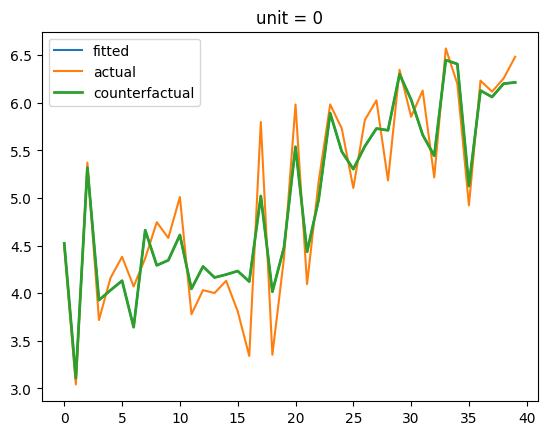

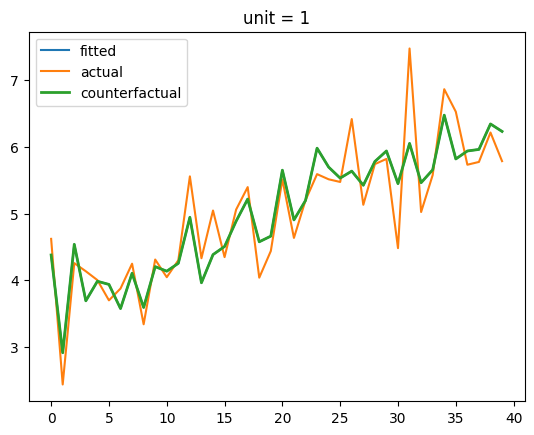

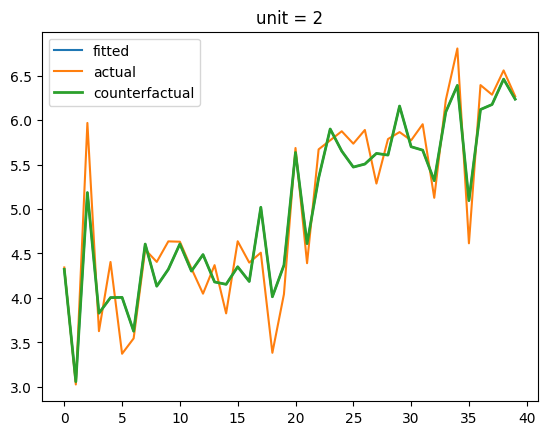

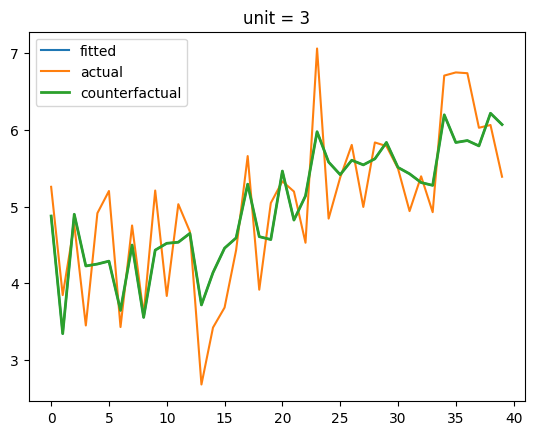

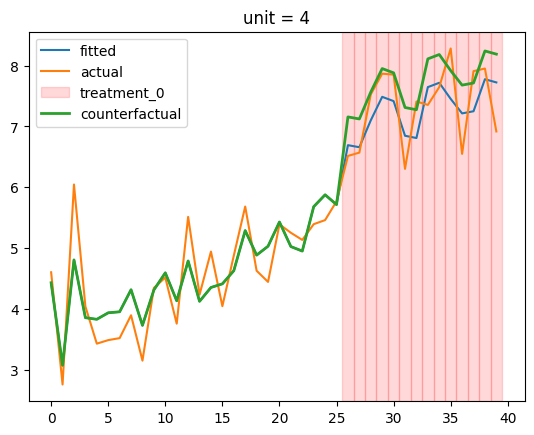

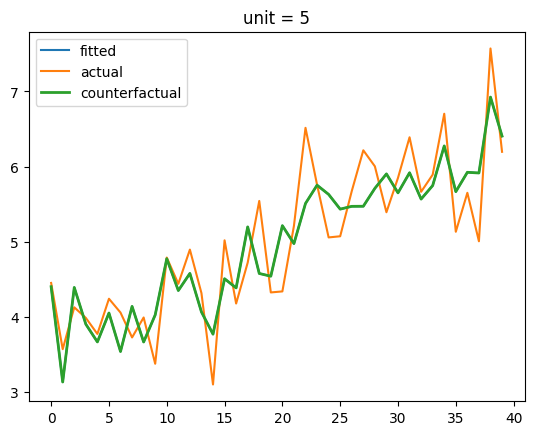

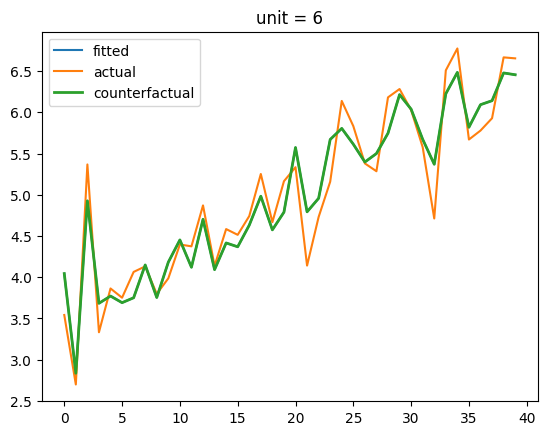

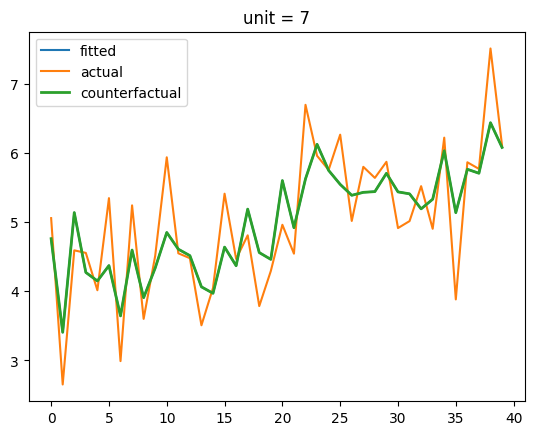

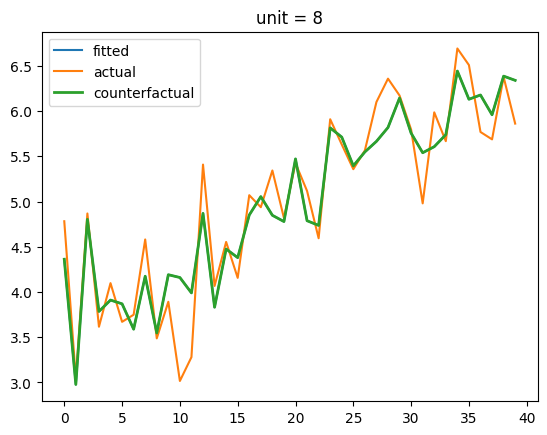

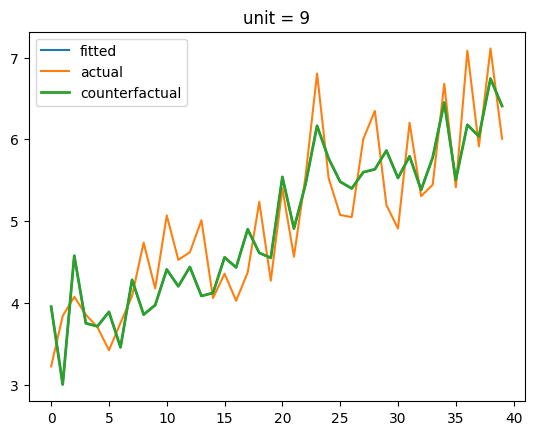

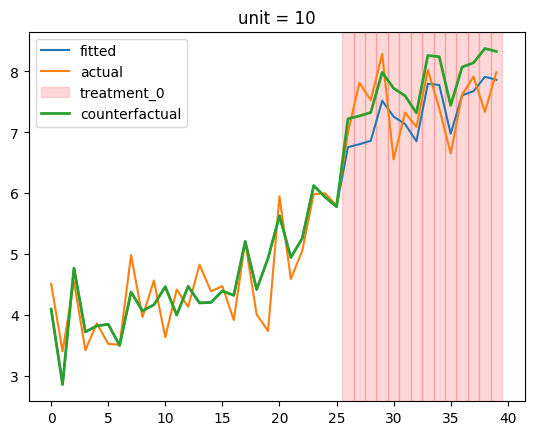

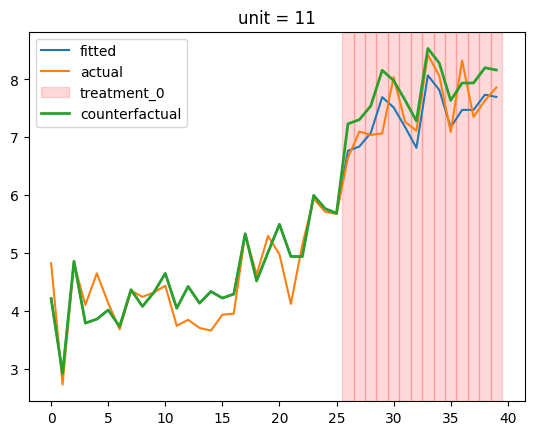

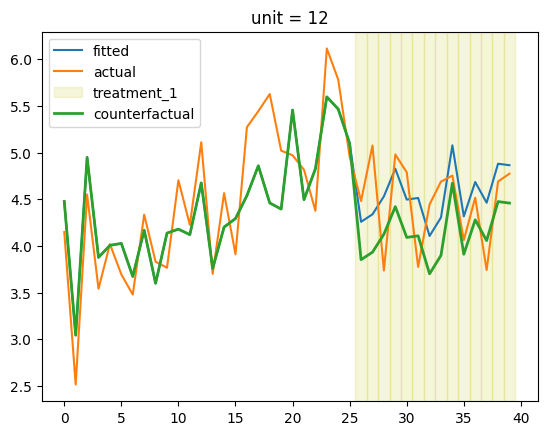

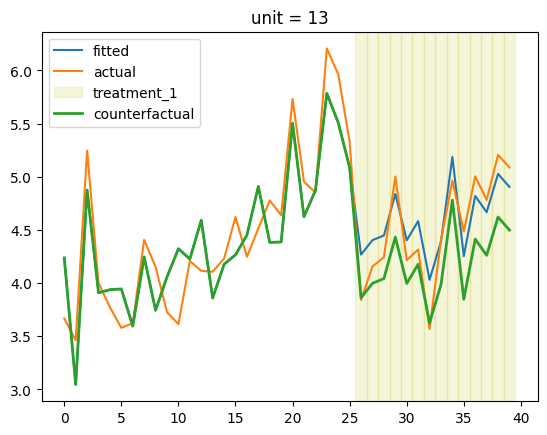

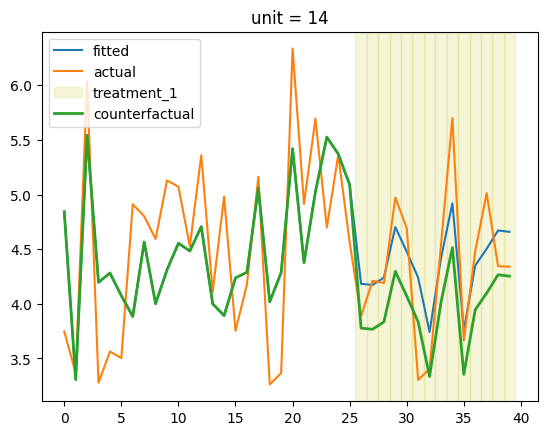

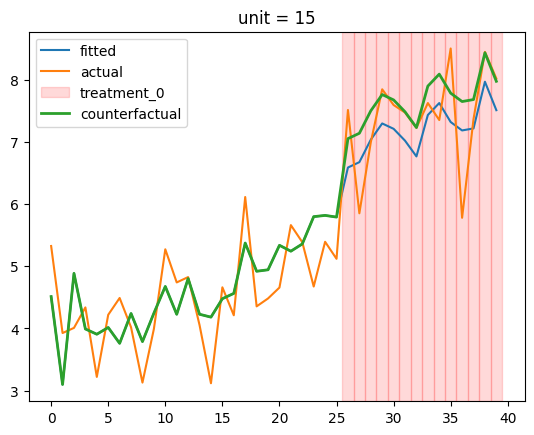

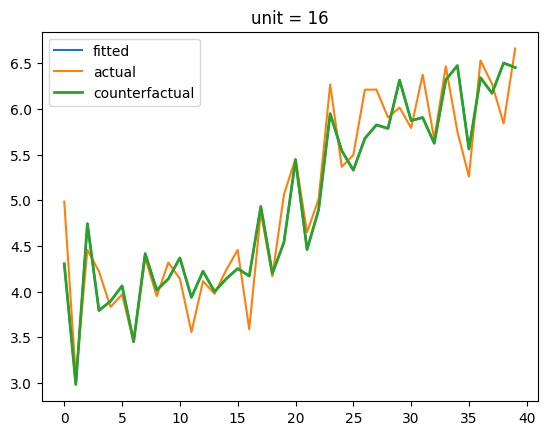

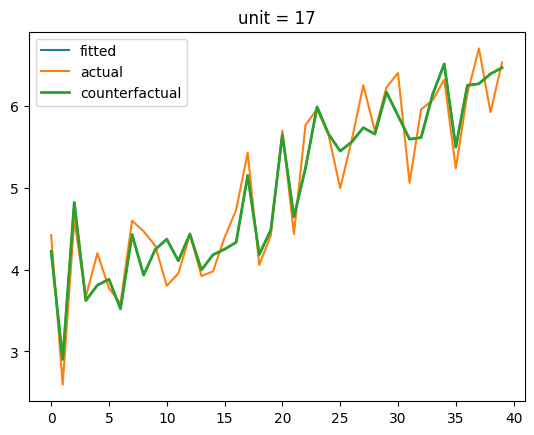

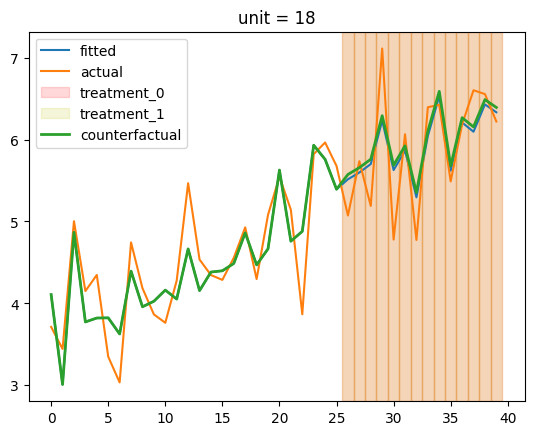

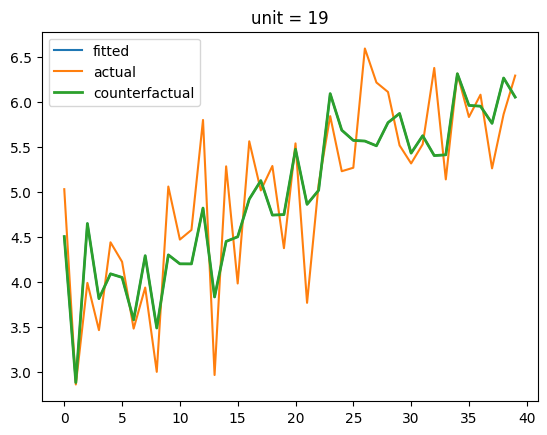

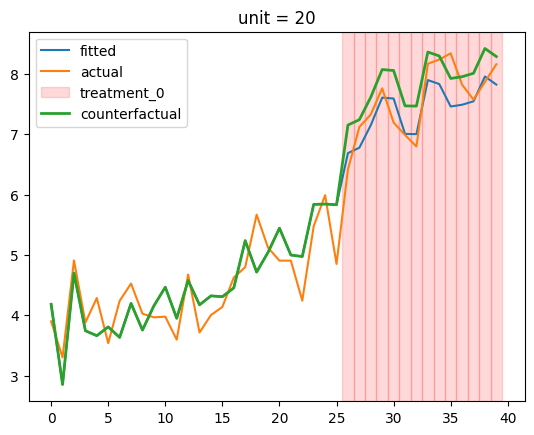

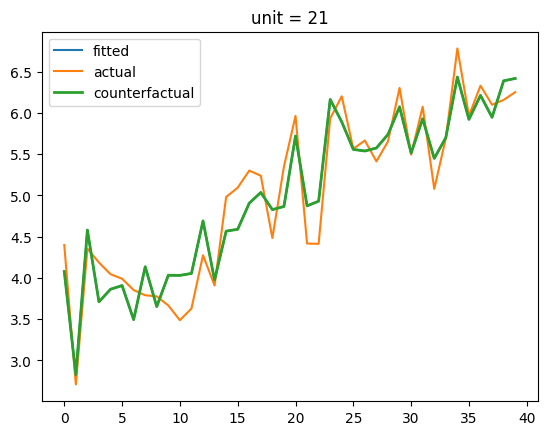

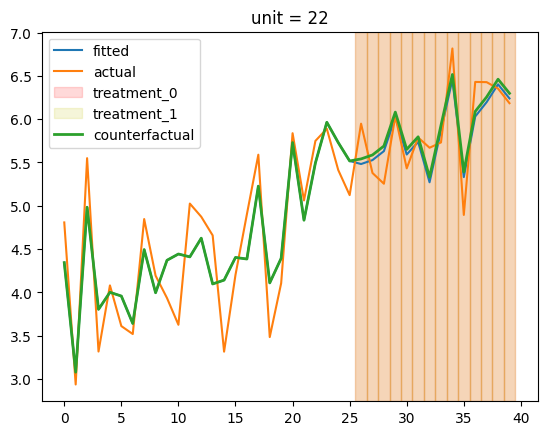

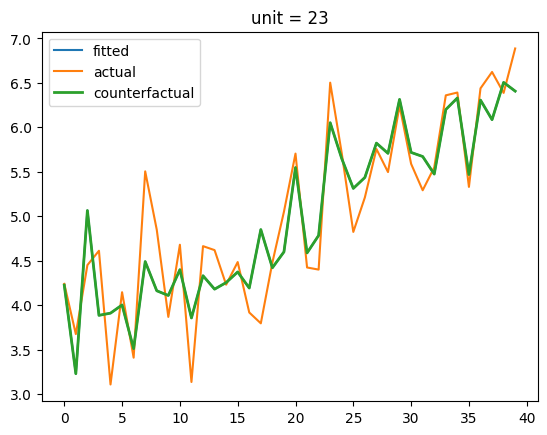

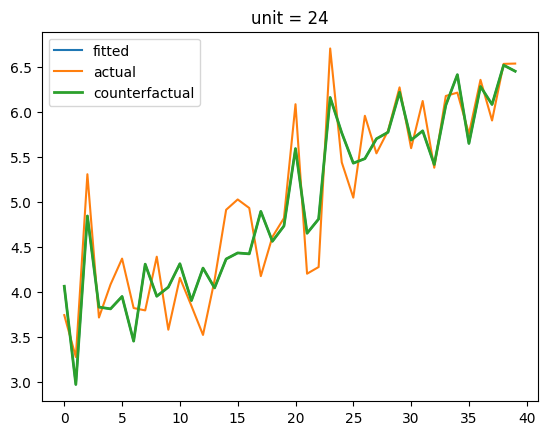

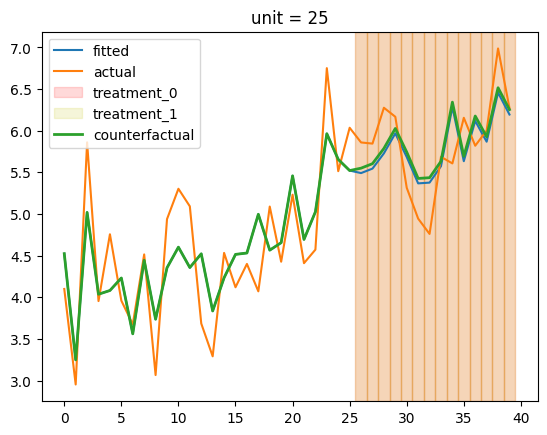

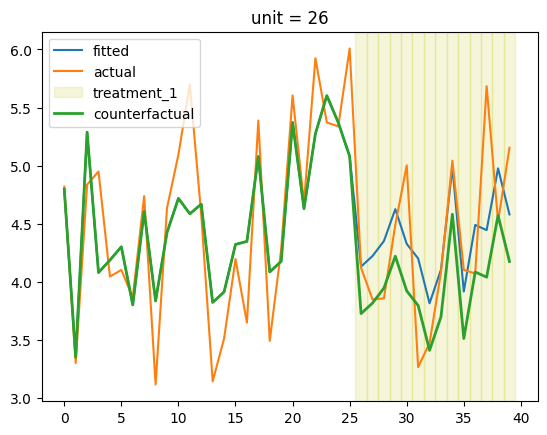

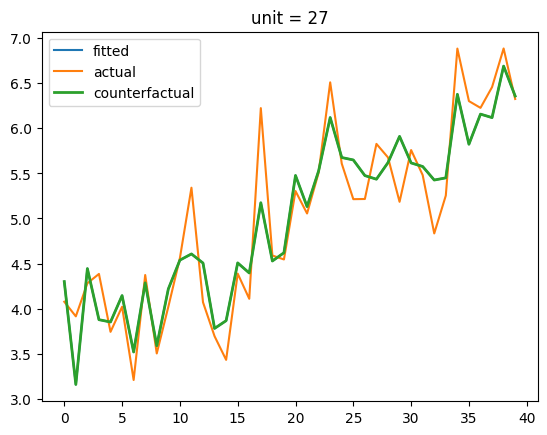

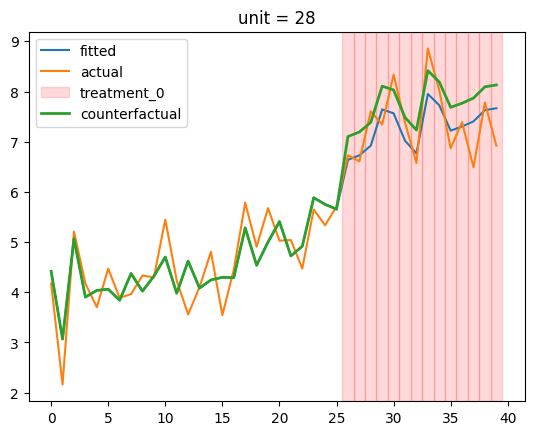

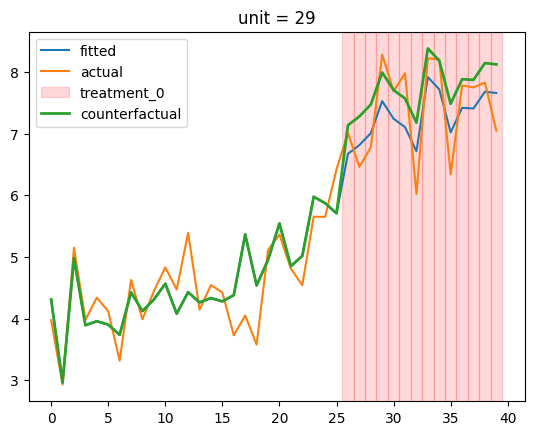

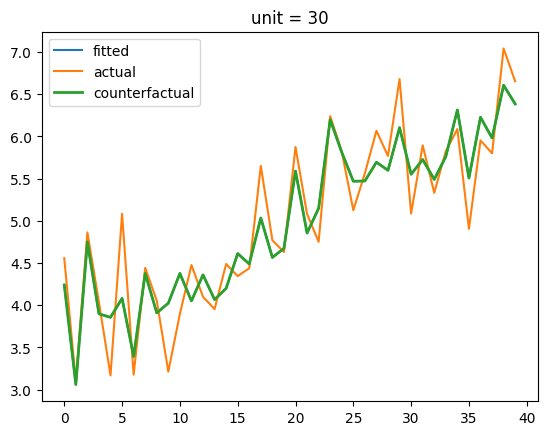

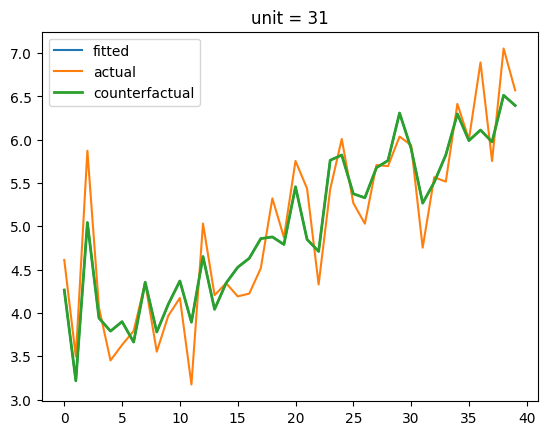

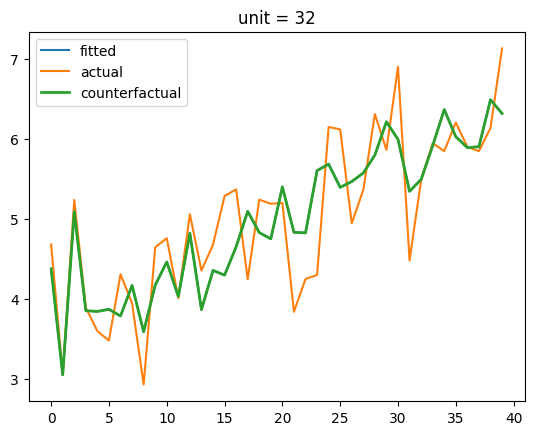

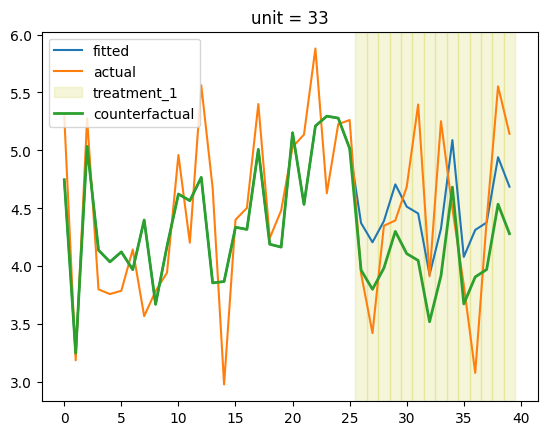

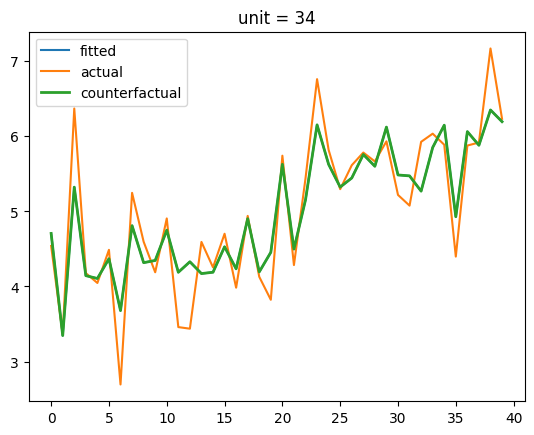

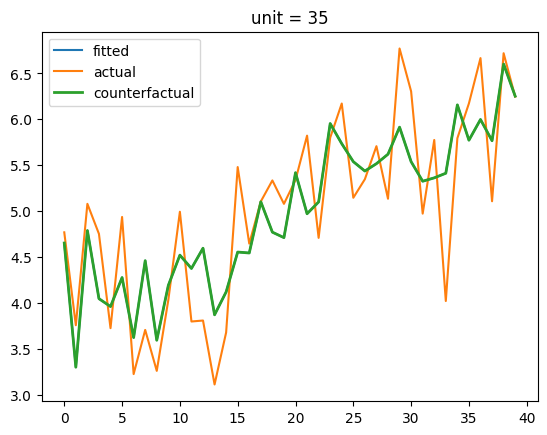

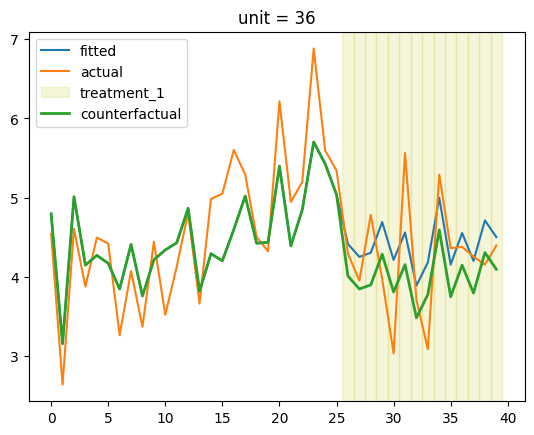

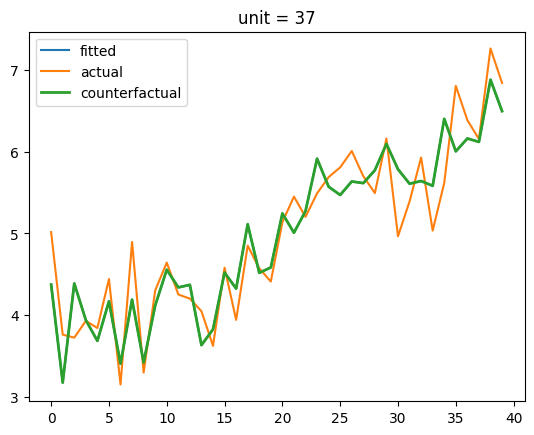

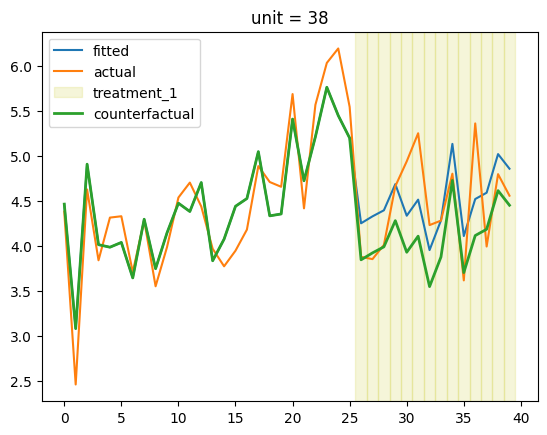

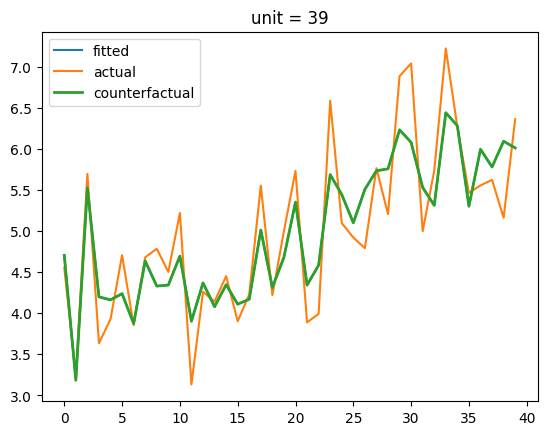

In [16]:
trt_cols = ['r', 'y', 'cyan']

for j in df['unit'].unique():
    plt.figure()
    plt.plot(fit['fittedvalues'][j], label='fitted')
    plt.plot(fit['fittedvalues'][j]+fit['resid'][j], label=f'actual')
    
    counterfactual = fit['fittedvalues'][j].values.copy()
    for i, t in enumerate(TREAT_COLS):
        flip_off = False
        counterfactual += fit['params'][t] * df[t][df.unit == j].values
        for date, k in enumerate(df[t][df.unit == j]):
            if k > 0:
                plt.axvspan(date-.5, date+.5, color=trt_cols[i], alpha=.15, label=None if flip_off else t)
                flip_off = True
    
    plt.plot(counterfactual, label=f'counterfactual', lw=2)
    plt.legend(loc='best')
    plt.title(f'unit = {j}')

# do permutation inference

In [17]:
perms = permutation_inference(fit, num_draws=50, debug=True, seed=0, shifts=None)
perms.head()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [08:18<00:00,  9.98s/it]


,omega_0_1,omega_0_2,omega_0_3,omega_0_4,omega_0_5,omega_0_6,omega_0_7,omega_0_8,omega_0_9,omega_0_10,...,Intercept_35,time_numeric_35,Intercept_36,time_numeric_36,Intercept_37,time_numeric_37,Intercept_38,time_numeric_38,Intercept_39,time_numeric_39
0,0.000432,0.076657,0.000014,0.000541,0.000393,0.010416,0.024032,0.0,0.009258,0.083862,...,2.800959,0.071704,1.087557,0.037571,3.559191,0.073767,4.063387,0.020764,0.440084,0.058415
1,0.000432,0.076657,0.000014,0.000541,0.000393,0.010416,0.024032,0.0,0.009258,0.083862,...,3.834508,0.059739,4.247867,0.011484,3.564577,0.073467,4.064401,0.020945,3.835691,0.059708
2,0.000432,0.076657,0.000014,0.000541,0.000393,0.010416,0.024032,0.0,0.009258,0.083862,...,2.133058,0.065006,4.246328,0.011367,3.556346,0.073617,4.056736,0.021034,3.902329,0.055950
3,0.000432,0.076657,0.000014,0.000541,0.000393,0.010416,0.024032,0.0,0.009258,0.083862,...,3.758394,0.062649,-0.050914,0.042305,3.569240,0.073290,-0.204463,0.051452,3.894574,0.056371
4,0.000432,0.076657,0.000014,0.000541,0.000393,0.010416,0.024032,0.0,0.009258,0.083862,...,3.835101,0.059716,4.245457,0.011478,3.557032,0.073776,1.754048,0.030765,3.915475,0.055606


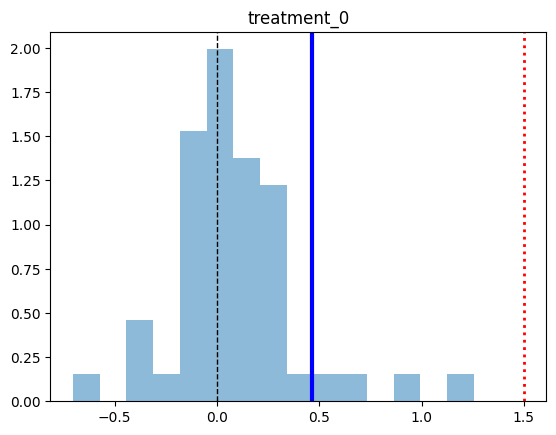

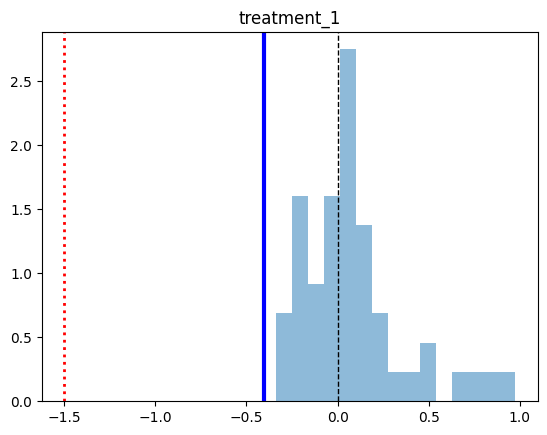

In [18]:
for t, c in enumerate(fit['treatment_cols']):
    plt.figure()
    plt.title(c)
    plt.hist(fit['permutation_inference_info']['params_permute'][c], bins=15, alpha=.5, density=True)
    plt.axvline(fit['params'][c], lw=3, c='b', label='estimate')
    plt.axvline(0, lw=1, ls='--', c='k')
    plt.axvline((-1)**t * 1.5, lw=2, c='r', label='truth', ls=':')

In [19]:
fit['permutation_inference_info']['params_permute'][TREAT_COLS].corr()

,treatment_0,treatment_1
treatment_0,1.000000,0.673494
treatment_1,0.673494,1.000000
